In [273]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [274]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings

In [275]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [276]:
print(jax.default_backend())

gpu


In [277]:
def Lorenz1960(vals, t):

  A_val, F_val, G_val = vals

  A_t = -(1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  F_t = (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  G_t = -(1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)

  vals_t = [A_t, F_t, G_t]

  return vals_t

In [278]:
t0, tfinal = 0.0, 7.5

In [279]:
k = 1.0
l = 2.0

k_sqr = k**2
l_sqr = l**2

In [280]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [281]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [282]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [283]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(3*self.units)(b)
    return out

In [284]:
def define_collocation_points(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  As = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Fs = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Gs = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Es = (1/4)*((As**2/l**2) + (Fs**2/k**2) + (2*(Gs**2)/(k**2 + l**2)))
  Vs = (1/2)*(As**2 + Fs**2 + 2*(Gs**2))

  sensor_points = np.column_stack((As, Fs, Gs, Es, Vs))

  return (ode_points, sensor_points)

In [285]:
(de_points, sensors) = define_collocation_points([t0, tfinal], 1000)
print(de_points.shape, sensors.shape)

(1000, 1) (1000, 5)


In [286]:
t_init_model = jnp.full((100, ), 1.0, dtype = jnp.float64)

In [287]:
print(de_points.dtype)
print(sensors.dtype)
print(t_init_model.dtype)

float64
float64
float64


In [288]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]

    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [289]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

    A_t_loss_w = 1.0
    F_t_loss_w = 10.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0
    V_loss_w = 1.0
    
    E_0_val = z[:, -2]
    V_0_val = z[:, -1]
    
    A_val = var(t, z, 0, params)
    F_val = var(t, z, 1, params)
    G_val = var(t, z, 2, params)
    
    A_t_val = var_t(t, z, 0, params)
    F_t_val = var_t(t, z, 1, params)
    G_t_val = var_t(t, z, 2, params)

    # print(A_t_val.shape, F_t_val.shape, G_t_val.shape)

    # print("-----------------------------------------------------")
    # A_t_max = jnp.max(A_t_val)
    # F_t_max = jnp.max(F_t_val)
    # G_t_max = jnp.max(G_t_val)

    # print(A_t_max, F_t_max, G_t_max)
    # print("-----------------------------------------------------")
    
    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)
        
    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss
    
    return final_loss

@jax.jit
def train_step(params, pdes, z):
    t = pdes[:,0]
    
    return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [290]:
def train_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [291]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [292]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

16640


In [293]:
epochs = 1000
params, loss = train_network(params, de_points, sensors, epochs)

batch size: 100
Loss in epoch 0: 0.06169916961477224
Loss in epoch 100: 0.007572405498183482
Loss in epoch 200: 0.0058385680861707855
Loss in epoch 300: 0.0051239673513299566
Loss in epoch 400: 0.0035794609235661745
Loss in epoch 500: 0.003238697966228459
Loss in epoch 600: 0.0028793537153526927
Loss in epoch 700: 0.0022174761079783666
Loss in epoch 800: 0.002201216455451551
Loss in epoch 900: 0.0018203251769631729


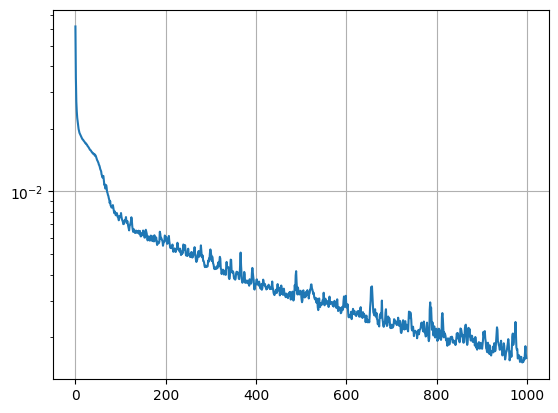

In [294]:
plt.semilogy(loss)
plt.grid()

In [295]:
n = 500
t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(-1.0, 1.0, size=(1,))
F_data = np.random.uniform(-1.0, 1.0, size=(1,))
G_data = np.random.uniform(-1.0, 1.0, size=(1,))
E_data = (1/4)*((A_data**2/l**2) + (F_data**2/k**2) + (2*(G_data**2)/(k**2 + l**2)))
V_data = (1/2)*(A_data**2 + F_data**2 + 2*(G_data**2))

init_data_rk = np.column_stack((A_data, F_data, G_data))
init_data_rk = np.squeeze(init_data_rk)

init_data_model = np.column_stack((A_data, F_data, G_data, E_data, V_data))
init_data_model = np.squeeze(init_data_model)
print(init_data_model.shape)

z = np.repeat(np.expand_dims(init_data_model, axis=0), len(t), axis=0)
print(z.shape)

(5,)
(500, 5)


In [296]:
sol_rk = odeint(Lorenz1960, init_data_rk, t)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))
V_rk = (1/2)*(A_rk**2 + F_rk**2 + 2*(G_rk**2))

In [297]:
A_model = jax.vmap(var_model, [0, 0, None, None])(t, z, 0, params)
F_model = jax.vmap(var_model, [0, 0, None, None])(t, z, 1, params)
G_model = jax.vmap(var_model, [0, 0, None, None])(t, z, 2, params)
E_model = (1/4)*((A_model**2/l**2) + (F_model**2/k**2) + (2*(G_model**2)/(k**2 + l**2)))
V_model = (1/2)*(A_model**2 + F_model**2 + 2*(G_model**2))

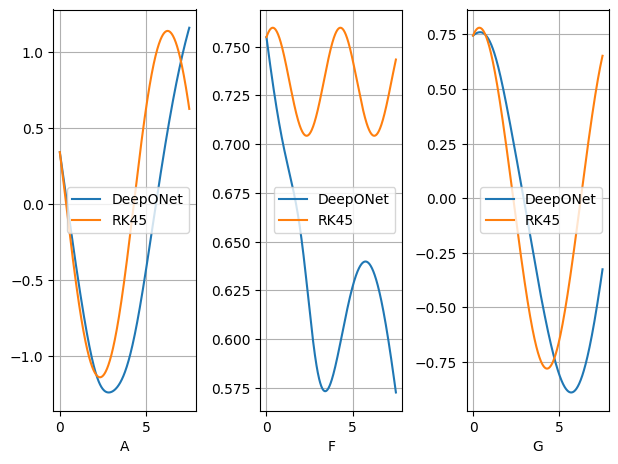

In [298]:
fig = plt.figure()

plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, A_model)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, F_model)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, G_model)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()

In [299]:
AFG_vals = jnp.column_stack((A_model, F_model, G_model))
E_vals = z[:, 3:4]
V_vals = z[:, 4:]

print(type(AFG_vals), AFG_vals.shape)
print(type(E_vals), E_vals.shape)
print(type(V_vals), V_vals.shape)

<class 'jaxlib.xla_extension.ArrayImpl'> (500, 3)
<class 'numpy.ndarray'> (500, 1)
<class 'numpy.ndarray'> (500, 1)


In [300]:
def obj_function_E(x, E_0) :

    A, F, G = x
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    E_err = (E-E_0)**2

    return E_err[0]


def obj_function_V(x, V_0) :
    
    A, F, G = x
    V = (1/2)*(A**2 + F**2 + 2*(G**2))
    V_err = (V-V_0)**2

    return V_err[0]

def obj_function_E_V(x, A_init, F_init, G_init, E_0, V_0) :

    factor = E_0/V_0
    factor = 1.0
    
    A, F, G = x
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    dist_err = (A - A_init)**2 + (F - F_init)**2 + (G - G_init)**2
    E_err = (E-E_0)**2
    V_err = (V-V_0)**2

    err_total = dist_err + 10*(E_err + factor*V_err)

    return err_total[0]

In [301]:
def find_min_E(x, E_0):

    return minimize(obj_function_E, x, (E_0,), method='BFGS', tol = 1e-6)


def find_min_V(x, V_0):

    return minimize(obj_function_V, x, (V_0,), method='BFGS', tol = 1e-6)


def find_min_E_V_out(x, E_0, V_0):

    x_init = jnp.copy(x)

    A_init = x_init[0]
    F_init = x_init[1]
    G_init = x_init[2]
    
    return minimize(obj_function_E_V, x, (A_init, F_init, G_init, E_0, V_0), method='BFGS', tol = 1e-7)

In [302]:
result_E_V = jax.vmap(find_min_E_V_out, (0, 0, 0), 0)(AFG_vals, E_vals, V_vals)
result_E_V = result_E_V.x

result_final = result_E_V

print(result_final.shape)

(500, 3)


In [303]:
A_final = result_final[:, 0]
F_final = result_final[:, 1]
G_final = result_final[:, 2]
E_final = (1/4)*((A_final**2/l**2) + (F_final**2/k**2) + (2*(G_final**2)/(k**2 + l**2)))
V_final = (1/2)*(A_final**2 + F_final**2 + 2*(G_final**2))

print(A_final.shape, F_final.shape, G_final.shape, E_final.shape, V_final.shape)

(500,) (500,) (500,) (500,) (500,)


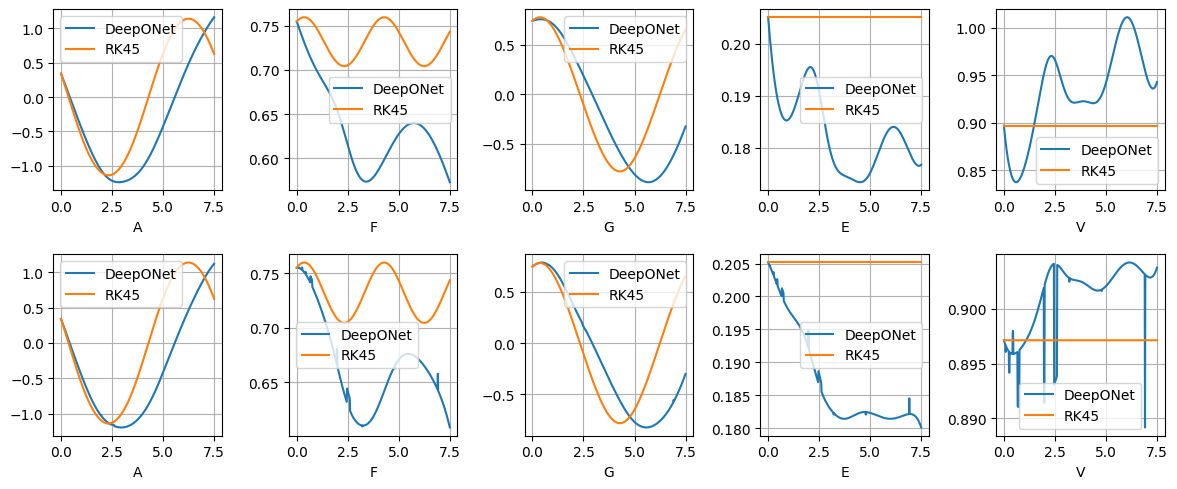

In [304]:
fig = plt.figure(figsize=(12, 5))

plt.subplot(2, 5, 1)
plt.tight_layout()
plt.plot(t, A_model)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 2)
plt.tight_layout()
plt.plot(t, F_model)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 3)
plt.tight_layout()
plt.plot(t, G_model)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 4)
plt.tight_layout()
plt.plot(t, E_model)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(2, 5, 5)
plt.tight_layout()
plt.plot(t, V_model)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 6)
plt.tight_layout()
plt.plot(t, A_final)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 7)
plt.tight_layout()
plt.plot(t, F_final)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 8)
plt.tight_layout()
plt.plot(t, G_final)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 9)
plt.tight_layout()
plt.plot(t, E_final)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(2, 5, 10)
plt.tight_layout()
plt.plot(t, V_final)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.show()

In [305]:
@jax.jit
def deriv_D(x, A_init, F_init, G_init, E_0, V_0) :

    factor_dist = 0.0
    factor_E = 1.0 
    factor_V = E_0/V_0
    factor_V = 1.0

    A = x[0]
    F = x[1]
    G = x[2]

    dE_dA = A/(2*(l**2))
    dE_dF = F/(2*(k**2))
    dE_dG = G/(k**2 + l**2)

    dV_dA = A
    dV_dF = F
    dV_dG = 2*G
  
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    dD_dA = factor_dist*2*(A-A_init) + 2*factor_E*(E-E_0)*dE_dA + 2*factor_V*(V-V_0)*dV_dA
    dD_dF = factor_dist*2*(F-F_init) + 2*factor_E*(E-E_0)*dE_dF + 2*factor_V*(V-V_0)*dV_dF
    dD_dG = factor_dist*2*(G-G_init) + 2*factor_E*(E-E_0)*dE_dG + 2*factor_V*(V-V_0)*dV_dG

    deriv_D_arr = jnp.array([dD_dA, dD_dF, dD_dG])

    return deriv_D_arr


In [306]:
@jax.jit
def func_D(x, A_init, F_init, G_init, E_0, V_0) :

    factor_dist = 0.0
    factor_E = 1.0
    factor_V = E_0/V_0
    factor_V = 1.0
    
    A = x[0]
    F = x[1]
    G = x[2]
    
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    dist_err = (A-A_init)**2 + (F-F_init)**2 + (G-G_init)**2

    D = factor_dist*dist_err + factor_E*(E-E_0)**2 + factor_V*(V-V_0)**2

    D_arr = jnp.array([D])

    return D_arr

In [307]:
@jax.jit
def find_rec(x):
    
    x = x + jnp.finfo(jnp.float64).eps
    return 1/x

In [308]:
@jax.jit
def wolfe_conds(args):

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, A_init, F_init, G_init, E_0, V_0, iter = args

    cond_1 = next_f - curr_f - c1*alpha*(curr_grad.T@p)
    cond_2 = next_grad.T@p - c2*(curr_grad.T@p)

    cond_1_bool = jax.lax.cond(cond_1[0][0] > 0.0 , lambda x: True, lambda x: False, None)
    cond_2_bool = jax.lax.cond(cond_2[0][0] < 0.0 , lambda x: True, lambda x: False, None)
    cond_3_bool = jax.lax.cond(alpha >= 1e-3 , lambda x: True, lambda x: False, None)

    wolfe_bool = jnp.logical_or(cond_1_bool, cond_2_bool)
    final_bool = jnp.logical_and(wolfe_bool, cond_3_bool)

    return final_bool

In [309]:
@jax.jit
def update_alpha(args) :

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, A_init, F_init, G_init, E_0, V_0, iter = args

    alpha = alpha*0.1
    iter = iter + 1
        
    next_x = curr_x + alpha*p
    next_f = func_D(next_x, A_init, F_init, G_init, E_0, V_0)
    next_grad = deriv_D(next_x, A_init, F_init, G_init, E_0, V_0) 
   
    return (alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, A_init, F_init, G_init, E_0, V_0, iter)


In [310]:
@jax.jit
def BFGS(x, x_init, E_0, V_0) :

    iter = 0
    init_iter = 0
    alpha = 1.0
    c1 = 1e-4
    c2 = 0.9
    I_3 = jnp.identity(3, dtype = jnp.float64)
    B_0_inv = jnp.identity(3, dtype = jnp.float64)

    x_0 = x
    x_0 = jnp.reshape(x_0, (-1, 1))

    A_init = x_init[0]
    F_init = x_init[1]
    G_init = x_init[2]

    E_init = (1/4)*((A_init**2/l**2) + (F_init**2/k**2) + (2*(G_init**2)/(k**2 + l**2)))
    V_init = (1/2)*(A_init**2 + F_init**2 + 2*(G_init**2))

    D_0 = func_D(x_0, A_init, F_init, G_init, E_0, V_0)
    gradD_0 = deriv_D(x_0, A_init, F_init, G_init, E_0, V_0)

    p = -1.0*alpha*(B_0_inv@gradD_0)

    next_x = x_0 + alpha*p
    next_D = func_D(next_x, A_init, F_init, G_init, E_0, V_0)
    next_gradD = deriv_D(next_x, A_init, F_init, G_init, E_0, V_0)

    init_args = (alpha, x_0, D_0, gradD_0, next_x, next_D, next_gradD, p, c1, c2, A_init, F_init, G_init, E_0, V_0, init_iter)
    
    step, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

    x_1 = x_0 - step*(B_0_inv@gradD_0)

    while iter < 10:

        delta_x = x_1 - x_0

        D_1 = func_D(x_1, A_init, F_init, G_init, E_0, V_0)
        gradD_1 = deriv_D(x_1, A_init, F_init, G_init, E_0, V_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        B_1_inv = ((I_3 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_3 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))   
        p = -1.0*alpha*(B_1_inv@gradD_1)
        
        next_x = x_1 + alpha*p
        next_D = func_D(next_x, A_init, F_init, G_init, E_0, V_0)
        next_gradD = deriv_D(next_x, A_init, F_init, G_init, E_0, V_0) 
                  
        init_args = (alpha, x_1, D_1, gradD_1, next_x, next_D, next_gradD, p, c1, c2, A_init, F_init, G_init, E_0, V_0, init_iter)

        step, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

        x_next = x_1 - step*(B_1_inv@gradD_1)

        x_0 = x_1
        x_1 = x_next

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter = iter + 1


    A = x_1[0]
    F = x_1[1]
    G = x_1[2]

    A = jnp.reshape(A, (-1, ))[0]
    F = jnp.reshape(F, (-1, ))[0]
    G = jnp.reshape(G, (-1, ))[0]
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    E_compare = jnp.column_stack((E, E_0))
    V_compare = jnp.column_stack((V, V_0))

    return A, F, G

In [311]:
@jax.jit
def find_min_E_V(AFG_list, E_0, V_0) :

    A = AFG_list[0]
    F = AFG_list[1]
    G = AFG_list[2]

    x = jnp.column_stack((A, F, G))
    x_init = jnp.copy(x)

    return jax.vmap(BFGS, (0, 0, 0, 0), 0)(x, x_init, E_0, V_0)

In [312]:
A_in, F_in, G_in = jax.vmap(find_min_E_V, (0, 0, 0), 0)(AFG_vals, E_vals, V_vals)
E_in = (1/4)*((A_in**2/l**2) + (F_in**2/k**2) + (2*(G_in**2)/(k**2 + l**2)))
V_in = (1/2)*(A_in**2 + F_in**2 + 2*(G_in**2))

result_E_V_out = jax.vmap(find_min_E_V_out, (0, 0, 0), 0)(AFG_vals, E_vals, V_vals)
result_E_V_out = result_E_V_out.x

A_out = result_E_V_out[:, 0]
F_out = result_E_V_out[:, 1]
G_out = result_E_V_out[:, 2]
E_out = (1/4)*((A_out**2/l**2) + (F_out**2/k**2) + (2*(G_out**2)/(k**2 + l**2)))
V_out = (1/2)*(A_out**2 + F_out**2 + 2*(G_out**2))

print(A_in.shape, A_out.shape)

(500, 1) (500,)


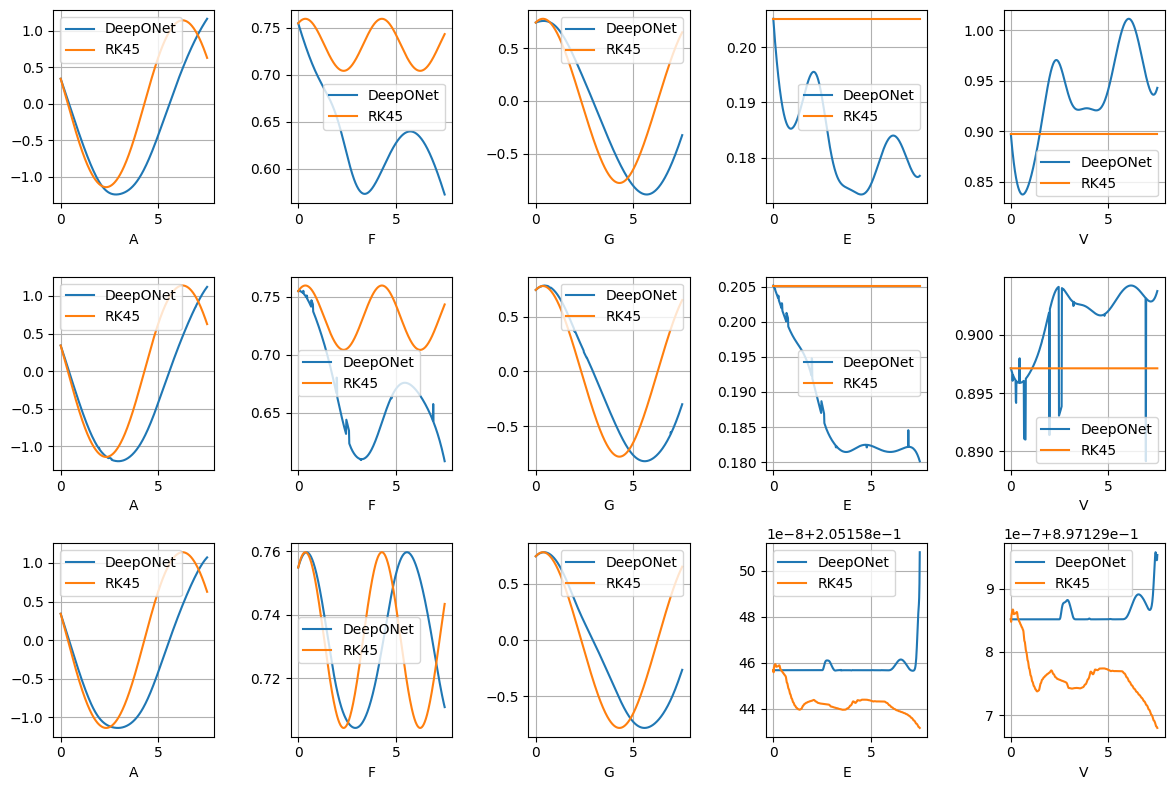

In [313]:
fig = plt.figure(figsize=(12, 8))

plt.subplot(3, 5, 1)
plt.tight_layout()
plt.plot(t, A_model)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 2)
plt.tight_layout()
plt.plot(t, F_model)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 3)
plt.tight_layout()
plt.plot(t, G_model)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 4)
plt.tight_layout()
plt.plot(t, E_model)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(3, 5, 5)
plt.tight_layout()
plt.plot(t, V_model)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 6)
plt.tight_layout()
plt.plot(t, A_out)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 7)
plt.tight_layout()
plt.plot(t, F_out)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 8)
plt.tight_layout()
plt.plot(t, G_out)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 9)
plt.tight_layout()
plt.plot(t, E_out)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(3, 5, 10)
plt.tight_layout()
plt.plot(t, V_out)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 11)
plt.tight_layout()
plt.plot(t, A_in)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 12)
plt.tight_layout()
plt.plot(t, F_in)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 13)
plt.tight_layout()
plt.plot(t, G_in)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 14)
plt.tight_layout()
plt.plot(t, E_in)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(3, 5, 15)
plt.tight_layout()
plt.plot(t, V_in)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.show()

In [314]:
class ClosestPoint(nn.Module):

    E_0: float
    V_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        A, F, G = find_min_E_V(inputs, self.E_0, self.V_0)
    
        return A, F, G

In [315]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]


    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)


    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
      
    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A, F, G = ClosestPoint(E_0, V_0)([A, F, G])
      
    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [316]:
@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Closs(params, t, z):
    
    A_t_loss_w = 1.0
    F_t_loss_w = 10.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 0.0
    V_loss_w = 0.0
    
    E_0_val = z[:, -2]
    V_0_val = z[:, -1]
    
    A_val = Cvar(t, z, 0, params)
    F_val = Cvar(t, z, 1, params)
    G_val = Cvar(t, z, 2, params)
    
    A_t_val = Cvar_t(t, z, 0, params)  
    F_t_val = Cvar_t(t, z, 1, params)
    G_t_val = Cvar_t(t, z, 2, params)

    # A_t_val_mask = jnp.where(jnp.abs(A_t_val) > 1.0)
    # F_t_val_mask = jnp.where(jnp.abs(F_t_val) > 1.0)
    # G_t_val_mask = jnp.where(jnp.abs(G_t_val) > 1.0)

    # final_mask = jnp.logical_or(A_t_val_mask, F_t_val_mask)
    # final_mask = jnp.logical_or(final_mask, G_t_val_mask)

    # A_val = jnp.where(final_mask, 0., A_val)
    # F_val = jnp.where(final_mask, 0., F_val)
    # G_val = jnp.where(final_mask, 0., G_val)
    # A_t_val = jnp.where(final_mask, 0., A_t_val)
    # F_t_val = jnp.where(final_mask, 0., F_t_val)
    # G_t_val = jnp.where(final_mask, 0., G_t_val)    

    # A_t_val = jnp.where(jnp.abs(A_t_val) > 1.0, 0., A_t_val)
    # F_t_val = jnp.where(jnp.abs(F_t_val) > 1.0, 0., F_t_val)
    # G_t_val = jnp.where(jnp.abs(G_t_val) > 1.0, 0., G_t_val)

    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)  
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)

    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.25)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

    return final_loss

@jax.jit
def Ctrain_step(params, pdes, z):
  t = pdes[:,0]
    
  return jax.value_and_grad(Closs)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [317]:
def Ctrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-4
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)

    
    for i in range(epochs):

        batch_no = 0
    
        for (des_batch, z_batch) in ds:
    
            loss, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
            
            params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)
            
            epoch_loss[i] += loss

            batch_no = batch_no + 1

        epoch_loss[i] /= batch_size

        if i % 1  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [318]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 5), 1.0, dtype = jnp.float64 )

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [319]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

16640


In [320]:
Cparams = copy.deepcopy(params)

In [321]:
epochs = 200
Cparams, Closs = Ctrain_network(Cparams, de_points, sensors, epochs)

batch size: 100
Loss in epoch 0: 2.1095817491794424
Loss in epoch 1: 0.062462499720508165
Loss in epoch 2: 116.76952686494222
Loss in epoch 3: 52.18231999169784
Loss in epoch 4: 3838476.8315489907
Loss in epoch 5: 597045608.0252118
Loss in epoch 6: 2310.0907000945085
Loss in epoch 7: 1302308857.8055239
Loss in epoch 8: 11164187999.018705
Loss in epoch 9: 5799447.949383859
Loss in epoch 10: 62735.29688368223
Loss in epoch 11: 73169.53452393335
Loss in epoch 12: 4440244.9656888405
Loss in epoch 13: 36241.10313338478
Loss in epoch 14: 1625.8383100921494
Loss in epoch 15: 2233755.7962904363
Loss in epoch 16: 10189.445789440348
Loss in epoch 17: 1129331.9382165244
Loss in epoch 18: 19847.44216098544
Loss in epoch 19: 1911194.8311371168
Loss in epoch 20: 24423.18644743205
Loss in epoch 21: 15781.484420475932
Loss in epoch 22: 16654.70635617702
Loss in epoch 23: 16509.71211604815
Loss in epoch 24: 16121.81409067343
Loss in epoch 25: 16026.063698424832
Loss in epoch 26: 15728.006009324828
Loss

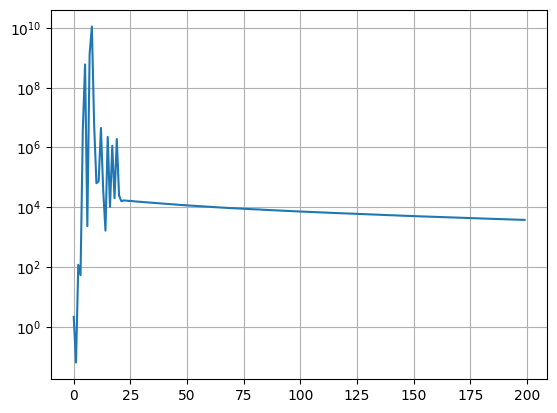

In [322]:
plt.semilogy(Closs)
plt.grid()

In [323]:
A = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 0, Cparams)
F = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 1, Cparams)
G = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 2, Cparams)
E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
V = (1/2)*(A**2 + F**2 + 2*(G**2))

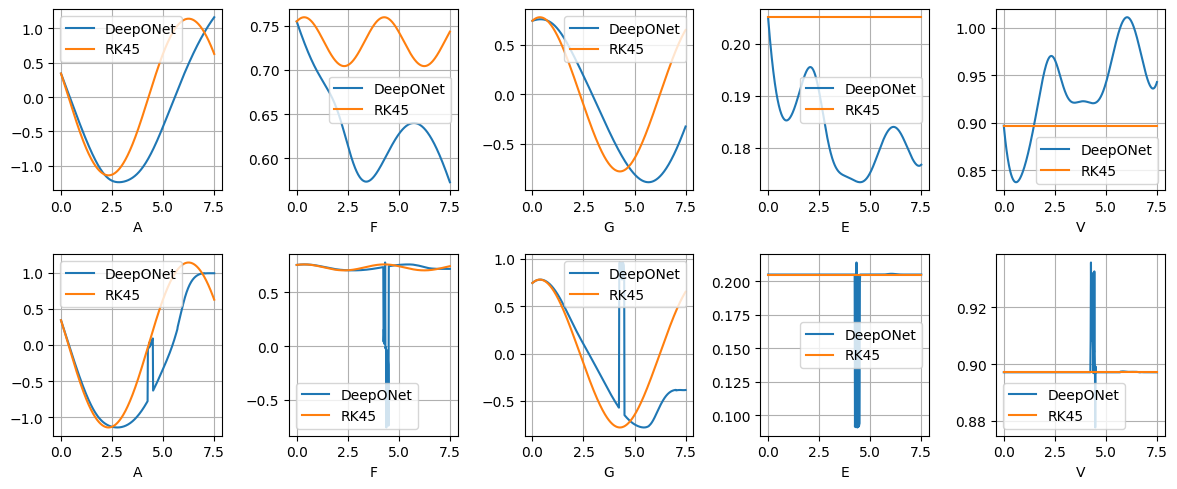

In [324]:
fig = plt.figure(figsize=(12, 5))

plt.subplot(2, 5, 1)
plt.tight_layout()
plt.plot(t, A_model)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 2)
plt.tight_layout()
plt.plot(t, F_model)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 3)
plt.tight_layout()
plt.plot(t, G_model)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 4)
plt.tight_layout()
plt.plot(t, E_model)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(2, 5, 5)
plt.tight_layout()
plt.plot(t, V_model)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 6)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 7)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 8)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 9)
plt.tight_layout()
plt.plot(t, E)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(2, 5, 10)
plt.tight_layout()
plt.plot(t, V)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.show()